# Sentiment Analysis

In [1]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
print(os.listdir()) 
import pandas as pd

['.ipynb_checkpoints', 'Sentiment_analysis.ipynb', '._Sentiment_analysis.ipynb']


## Preprocess Data 

In [4]:
df = pd.read_csv('../Local_csv/interventions_topics.csv')
df.head()



,text,gender,year,grupo,position
0,"Gracias, señora presidenta. Señorías, interven...",F,2003,Grupo Parlamentario Socialista,NaN
1,"Gracias, señora presidenta. El Bloque Nacional...",M,2003,Grupo Parlamentario Mixto,NaN
2,"Muchas gracias, señora presidenta. Mi grupo va...",M,2003,Grupo Parlamentario de Coalición Canaria,NaN
3,"Señora presidenta, señorías, arratsalde on, bu...",M,2003,Grupo Parlamentario Vasco (EAJ-PNV),NaN
4,"Ya he finalizado, señora presidenta, muchas gr...",M,2003,Grupo Parlamentario Vasco (EAJ-PNV),NaN


In [5]:
from nltk.corpus import udhr
print([f for f in udhr.fileids() if 'Spanish' in f])


['Spanish-Latin1', 'Spanish_Espanol-Latin1']


In [6]:
import nltk
nltk.download('punkt')

from nltk.tokenize.punkt import PunktSentenceTokenizer, PunktTrainer
from nltk.corpus import udhr

# Download Spanish sample text (used for training)
nltk.download('udhr')
spanish_text = udhr.raw('Spanish_Espanol-Latin1')

# Train a tokenizer on Spanish text
trainer = PunktTrainer()
trainer.INCLUDE_ALL_COLLOCS = True
trainer.train(spanish_text)

spanish_tokenizer = PunktSentenceTokenizer(trainer.get_params())



[nltk_data] Downloading package punkt to /Users/paula/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package udhr to /Users/paula/nltk_data...
[nltk_data]   Package udhr is already up-to-date!


In [7]:
df = df[df['gender'].isin(['F', 'M'])].dropna(subset=['text'])

# Remove formal greetings
def remove_greetings(text):
    greetings = [
        'gracias', 'muchas gracias', 'señora presidenta', 'señor presidente',
        'señorías', 'muy buenos días', 'buenas tardes', 'buenos días', 'muchísimas gracias'
    ]
    import re
    sentences = re.split(r'(?<=[.!?])\\s+', text.strip())
    return ' '.join([s for s in sentences if not any(s.lower().startswith(g) for g in greetings)])

df['text_cleaned'] = df['text'].apply(remove_greetings)


## Sentiment analysisi

In [8]:
import nltk
from textblob import TextBlob
nltk.download('punkt')

# Step 1: Expand each intervention into individual sentences
sentence_rows = []

for _, row in df.iterrows():
    sentences = spanish_tokenizer.tokenize(row['text_cleaned'])
    for sent in sentences:
        sentence_rows.append({
            'sentence': sent,
            'year': row['year'],
            'speaker_gender': row['gender']
        })

df_sent = pd.DataFrame(sentence_rows)

# Step 2: Detect referenced gender in each sentence
def detect_target(sentence):
    female_refs = ['diputada', 'ministra', 'ella', 'señora', 'presidenta']
    male_refs = ['diputado', 'ministro', 'él', 'señor', 'presidente']
    
    sent_lower = sentence.lower()
    mentions_f = any(word in sent_lower for word in female_refs)
    mentions_m = any(word in sent_lower for word in male_refs)

    if mentions_f and not mentions_m:
        return 'F'
    elif mentions_m and not mentions_f:
        return 'M'
    elif mentions_f and mentions_m:
        return 'Both'
    return 'Unknown'

df_sent['gender_target'] = df_sent['sentence'].apply(detect_target)

# Step 3: Sentiment label with TextBlob
def get_sentiment_label(text):
    score = TextBlob(text).sentiment.polarity
    return 'Negative' if score < -0.1 else 'Positive' if score > 0.1 else 'Neutral'

df_sent['sentiment_label'] = df_sent['sentence'].apply(get_sentiment_label)
df_sent['word_count'] = df_sent['sentence'].apply(lambda x: len(x.split()))
df_sent['is_negative'] = df_sent['sentiment_label'].apply(lambda x: 1 if x == 'Negative' else 0)

# Step 4: Filter & Aggregate
filtered = df_sent[df_sent['gender_target'].isin(['F', 'M'])].copy()

agg_sentence = (
    filtered.groupby(['year', 'gender_target'])
    .agg({'is_negative': 'sum', 'word_count': 'sum'})
    .reset_index()
)
agg_sentence['neg_per_1000_words'] = (agg_sentence['is_negative'] / agg_sentence['word_count']) * 1000

# Step 5: Display result
print("Sentence-Level Negative Sentiment per 1000 Words by Gender and Year:")
print(agg_sentence)


[nltk_data] Downloading package punkt to /Users/paula/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Sentence-Level Negative Sentiment per 1000 Words by Gender and Year:
   year gender_target  is_negative  word_count  neg_per_1000_words
0  2003             F            6       28950            0.207254
1  2003             M           38      155241            0.244781
2  2013             F            7       25759            0.271750
3  2013             M           16       93528            0.171072
4  2023             F           11       30502            0.360632
5  2023             M           32      119320            0.268186


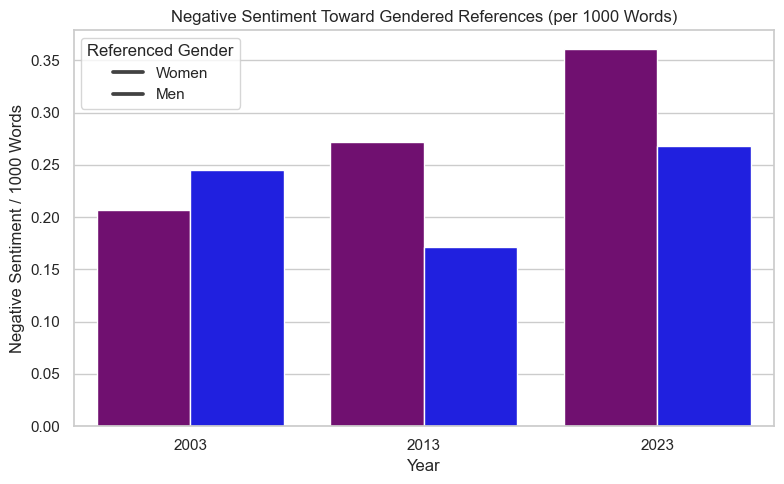

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=agg_sentence,
    x='year',
    y='neg_per_1000_words',
    hue='gender_target',
    palette={'F': 'purple', 'M': 'blue'}
)

# Labels
plt.title("Negative Sentiment Toward Gendered References (per 1000 Words)")
plt.ylabel("Negative Sentiment / 1000 Words")
plt.xlabel("Year")
plt.legend(title="Referenced Gender", labels=["Women", "Men"])
plt.tight_layout()
plt.show()


## Manual comprovation

In [12]:
# Selecciona 100 frases negativas
negativas = df_sent[df_sent['sentiment_label'] == 'Negative'].head(100)

# Las imprimimos bien ordenaditas
for idx, row in negativas.iterrows():
    print(f"{idx+1}. ({row['year']} | {row['speaker_gender']}) {row['sentence']}")


77. (2003 | F) En la actualidad, hay cuatro unidades que han sido certificadas por AENOR de acuerdo con la norma ISO 14001: El Retín (Cádiz), la base aérea de Getafe (Madrid), el campo de maniobras de El Palancar (Madrid) y el centro de ensayos de Torre Gorda (Cádiz).
95. (2003 | F) A pesar de que se nos diga que ya lo está haciendo el Gobierno, sería interesante que esta iniciativa se tuviera en consideración por esta Cámara porque pondría la base para empezar a avanzar en materia medioambiental.
172. (2003 | M) Sus manifestaciones hay que contextualizarlas en base a un acuerdo que tuvo lugar el mes de diciembre pasado en el plenario del Ayuntamiento de Barcelona.
192. (2003 | M) Estamos, pues, en contra de una acción preventiva y todavía más en contra, señor Aznar, de una acción unilateral, de una agresión sin el amparo de Naciones Unidas ni de la OTAN ni de la Unión Europea, que hasta ahora no se ha producido.
193. (2003 | M) Lo que sí se ha producido, señor Aznar, ha sido la deriva